## 任务 1 说明

**数据**：使用 PyTorch 生成 100 组带少量噪声的 (x, y) 数据，满足 y = 2x + 1，并用散点图展示。

**模型**：使用 `nn.Linear(1, 1)` 构建一个可学习的线性模型。训练过程中没有预先设定斜率 2 和截距 1，让模型自己从数据中学习。

**损失函数**：使用均方误差 `nn.MSELoss()` 衡量预测值与真实值的差距。

**训练过程**：使用随机梯度下降 `SGD`，学习率 0.05，迭代 2000 次。每次迭代计算损失、反向传播、更新参数。损失曲线显示损失从约 8 快速下降并稳定在接近 0 的位置。

**结果**：训练后学到斜率约为 1.9985（接近 2），截距约为 1.0060（接近 1）。用未参与训练的 x = 3.0 测试，模型预测 7.0016，真实值 7，误差很小。

**AI 协助**：我使用 AI 工具理解了 PyTorch 训练流程、排查了环境问题（如中文字体显示、内核选择），并解释了梯度下降的原理。

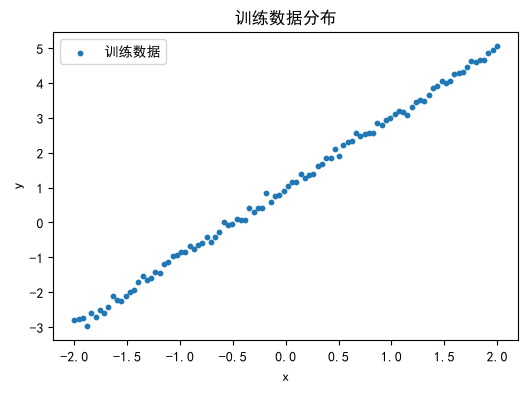

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  # 用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号

torch.manual_seed(42)

x = torch.linspace(-2, 2, 100).reshape(-1, 1)
y = 2 * x + 1 + 0.1 * torch.randn(x.shape)

plt.figure(figsize=(6, 4))
plt.scatter(x.numpy(), y.numpy(), s=10, label='训练数据')
plt.xlabel('x')
plt.ylabel('y')
plt.title('训练数据分布')
plt.legend()
plt.show()

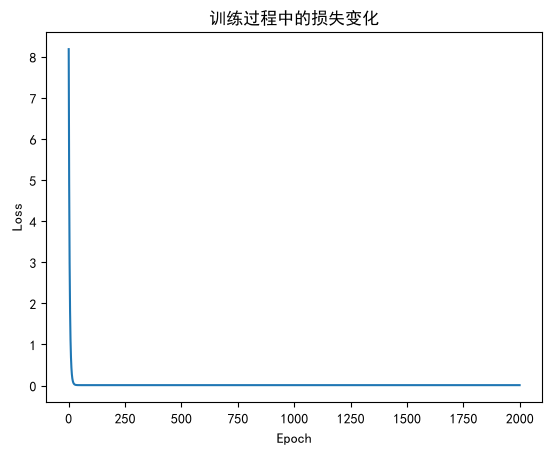

In [2]:
# 1. 定义可学习的线性模型（输入1维，输出1维）
model = nn.Linear(1, 1)

# 2. 损失函数：均方误差
criterion = nn.MSELoss()

# 3. 优化器：随机梯度下降，学习率设为0.05
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

# 4. 训练 2000 轮
losses = []
for epoch in range(2000):
    y_pred = model(x)
    loss = criterion(y_pred, y)
    
    optimizer.zero_grad()  # 梯度清零
    loss.backward()        # 反向传播
    optimizer.step()       # 更新参数
    
    losses.append(loss.item())

# 5. 画出损失下降曲线
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('训练过程中的损失变化')
plt.show()

In [3]:
# 1. 查看训练后学到的参数
w = model.weight.item()
b = model.bias.item()
print(f"训练后学到的斜率 w = {w:.4f} (真实值 2)")
print(f"训练后学到的截距 b = {b:.4f} (真实值 1)")

# 2. 用未参与训练的 x 值做预测
x_test = torch.tensor([[3.0]])
pred = model(x_test).item()
true_val = 2 * 3 + 1
print(f"\n测试 x = 3.0:")
print(f"模型预测值: {pred:.4f}")
print(f"真实值:     {true_val:.4f}")

训练后学到的斜率 w = 1.9985 (真实值 2)
训练后学到的截距 b = 1.0060 (真实值 1)

测试 x = 3.0:
模型预测值: 7.0016
真实值:     7.0000
